In [1]:
%cd ..
%pwd

/home/cveihmeyer_umass_edu/HeST


'/home/cveihmeyer_umass_edu/HeST'

In [2]:
import os
import sys
import HeST as hest
import HeST.Amherst_split_cpd_with_numba as examp
import numpy as np
import matplotlib.pyplot as plt
import HeST.Detection as detection
from numba import jit
# from tqdm import tqdm
from analysis.analysis_functions import *
import astropy.stats as astat
from scipy.interpolate import interp1d
import pickle
import glob

In [ ]:
# need to load in the evaporation file (which is a pickle) and make the basic plots


with open('./data/new_batch_pracrice.pkl', 'rb') as f:
    slurm_practice = pickle.load(f)





In [ ]:
plot_hist_flavors(slurm_practice)

In [9]:
phonon = np.linspace(0.3, 0.7, 3)
r_minus = np.linspace(0.3, 0.7, 3)
r_plus = np.linspace(0.3, 0.7, 3)


pp, rm, rp = np.meshgrid(phonon, r_minus, r_plus)

combinations = np.round(np.column_stack((pp.ravel(), rm.ravel(), rp.ravel())), 3)

In [10]:
print(combinations)

[[0.3 0.3 0.3]
 [0.3 0.3 0.5]
 [0.3 0.3 0.7]
 [0.5 0.3 0.3]
 [0.5 0.3 0.5]
 [0.5 0.3 0.7]
 [0.7 0.3 0.3]
 [0.7 0.3 0.5]
 [0.7 0.3 0.7]
 [0.3 0.5 0.3]
 [0.3 0.5 0.5]
 [0.3 0.5 0.7]
 [0.5 0.5 0.3]
 [0.5 0.5 0.5]
 [0.5 0.5 0.7]
 [0.7 0.5 0.3]
 [0.7 0.5 0.5]
 [0.7 0.5 0.7]
 [0.3 0.7 0.3]
 [0.3 0.7 0.5]
 [0.3 0.7 0.7]
 [0.5 0.7 0.3]
 [0.5 0.7 0.5]
 [0.5 0.7 0.7]
 [0.7 0.7 0.3]
 [0.7 0.7 0.5]
 [0.7 0.7 0.7]]


In [11]:
# write a file name 
import time 
import os
# this will be used in the saving that we do later, so I should add this line to HeST basic script
name_directory =os.path.join('', time.strftime('%y%m%d', time.gmtime()))

import numpy as np
num_quasiparticles = np.random.randint(low = 10000, high= 60000, size=1000)

with open(os.path.join('parameters', 'sweep_momentum_probs.txt'), 'a+') as f:
    for i, eff in enumerate(combinations):
        f.write(f'/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_momentum_probs/trial_{i}.pkl')
        f.write(' ')
        f.write(' ')
        for ii in eff:
            f.write(f'{ii},')
        f.write('\n')


In [ ]:
# the goal of this is to sweep through the files, collect the channel sums, and then move save that and move on. 
import glob
file_list = glob.glob('./data/sample_1000/*')

channel_1 = np.empty(len(file_list))
channel_2 = np.empty(len(file_list))
for i, file in enumerate(file_list):
    with open(file, 'rb') as f:
        evap = pickle.load(f)
        channel_1[i] = len(evap.arrivalTimes_us[0])
        channel_2[i] = len(evap.arrivalTimes_us[1])
np.savetxt('./data/ch1_ch2_comparison/sample_run_data.txt', np.column_stack((channel_1, channel_2)))
config = {}
config['diff_prob'] = 0.8
config['refl_prob'] = 0.3
config['evap_eff'] = 0.6
config['num_qps'] = 10000
with open("config.txt", "w+") as file:
    for key, value in config.items():
        file.write(f"{key}={value}\n")

In [ ]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(channel_1, channel_2)
ax.set_aspect('equal',adjustable= 'box')
ax.set_xlim(0, 8000)
ax.set_ylim(0, 8000)

In [ ]:
templates = np.load('./data/dispersion_curves/templates.npy')
time = np.linspace(0, 10, 25000)
cpd1_scint_template = templates[0]
cpd2_scint_template = templates[1]
cpd1_evap_template = templates[2]
cpd2_evap_template = templates[3]
fig, ax = plt.subplots()
ax.plot(time, cpd1_scint_template, label= 'cpd1 scint')

ax.plot(time, cpd2_scint_template, label = 'cpd2 scint')
ax.plot(time, cpd1_evap_template, label = 'cpd1 evap')
ax.plot(time, cpd2_evap_template, label = 'cpd2 evap')
ax.set_title('Will Template Vs Old Template')
ax.legend()
ax.set_xlim(0, 2.5)

In [ ]:
# sampling rate is 1.25e6 per second: meaning that per each thing has 1/1.25e6 --> 0.8e-6 still the same as before. 
# now we need to save 
upper = int(5 * 2500)
lower = int(1.25*2500)
time = np.linspace(0, 10, 25000)
cpd1_scint_template = templates[0]
cpd2_scint_template = templates[1]
cpd1_evap_template = templates[2]
cpd2_evap_template = templates[3]
fig, ax = plt.subplots()
ax.plot(time[lower:upper], cpd1_scint_template[lower:upper], label= 'cpd1 scint')
ax.plot(time[lower:upper], cpd2_scint_template[lower:upper], label = 'cpd2 scint')
ax.plot(time[lower:upper], cpd1_evap_template[lower:upper], label = 'cpd1 evap')
ax.plot(time[lower:upper], cpd2_evap_template[lower:upper], label = 'cpd2 evap')
ax.set_title('Will Template Vs Old Template')
ax.legend()
ax.set_xlim(0, 2.5)

In [ ]:
print(time[-3] - time[-4])

 # this should be in us I think... 

In [ ]:
# need to load in the evaporation file (which is a pickle) and make the basic plots


with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_1.5_test.pkl', 'rb') as f:
    many_qps = pickle.load(f)
plot_hist_flavors(many_qps)
plot_stacked_hist(many_qps)
plot_waveform(many_qps)

In [5]:
time = np.arange(0, 9999 * 0.8e-6, 0.8e-6)

In [ ]:
cpd1_hits = np.histogram(many_qps.arrivalTimes_us[0], bins=3750, range = [0,3000])[0] * 10e-3
cpd2_hits = np.histogram(many_qps.arrivalTimes_us[1], bins=3750, range = [0,3000])[0] * 10e-3
plt.plot(time, np.convolve(cpd1_hits, cpd1_template))

plt.xlabel('Seconds')
plt.ylabel('Energy')
plt.title('CPD 1 pulse comparison')

In [ ]:
s1, s2, time = generate_waveform(many_qps)
plt.plot(time, s1)

In [ ]:
plt.hist(many_qps.arrivalTimes_us[0], bins=200, range = [0,3000])

In [6]:
# I want to read these in by height, and then I can move from there
h_10_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_10_*.pkl')
h_15_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_*.pkl')
h_5_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_5_*.pkl')
h_2_5_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_2.5_*.pkl')

In [ ]:
hex_colors = [
    "#FF5733", "#33FF57", "#3357FF", "#FF33A1", "#000000",
    "#33FFFF", "#A133FF", "#FF8C33", "#57FF33", "#FF3333",
    "#1E90FF", "#FFD700"  # Added Dodger Blue and Gold
]

markers = ["o", "s", "^", "v", "D", "X", "P", "*", "H", "<"]

all_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h*.pkl')
names = []
waveforms = []
fig, ax = plt.subplots(figsize=(16, 8))
for ii, f in enumerate(all_files):
    print(f)
    with open(f, 'rb') as file:
        evap = pickle.load(file)
    name = f.split('/')[-1][:-4]
    names.append(name)
    s1, s2, time = generate_waveform(evap)
    waveforms.append([s1, s2])
    ax.scatter(time, s1, color=hex_colors[ii],s=10 ,label=name + ' CPD1',  alpha=0.1 ) 
    # ax.plot(time, s1, label=name + ' CPD2') 


ax.legend()

    
    


In [ ]:
fig, ax = plt.subplots()
ax.plot(time[lower:upper] - 0.001, 88 * cpd1_evap_template[lower:upper] / 1921619327.2159166, label = 'cpd1 evap')

In [ ]:
file = all_files[0]
print(file.split('/'))
name = file.split('/')[-1]
print(name[:-4])

In [ ]:
# for each, I want to store the cpd time arrays, so we need a 3D thing

def extract_pulse(file_list):
    heights = []
    for ii, file in enumerate(file_list):
        with open(file, 'rb') as f:
            height = pickle.load(f)
        
        plot_stacked_hist(height, title=file_list[ii][-14:-4])
        plot_hist_flavors(height,title=file_list[ii][-14:-4] )
        cpd1 = height.arrivalTimes_us[0]
        cpd2 = height.arrivalTimes_us[1]
        heights.append(cpd1)
        heights.append(cpd2)
    return heights

h_15 = extract_pulse(h_15_files)

In [ ]:
plt.title(str(h_15_files[0])[-14:-4])
plt.hist(h_15[0], bins=200, range = (0,3000))

In [12]:
templates = np.load('./data/dispersion_curves/templates.npy')
time = np.linspace(0, 0.01, 25000)
cpd1_scint_template = templates[0]
cpd2_scint_template = templates[1]
cpd1_evap_template = templates[2]
cpd2_evap_template = templates[3]

In [ ]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/Test.pkl', 'rb') as f:
    evap = pickle.load(f)
# plot_stacked_hist(evap)
# plot_hist_flavors(evap)
plot_waveform(evap)
plt.plot(time - 0.0011, 110 * cpd2_evap_template)

In [ ]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/*.pkl')
for ii, f in enumerate(file_list):
    if ii%2==0 or ii%5==0:
        continue
    print(f)
    title = f.split('/')[-1][:-4]
    with open(f, 'rb') as file:
        evap = pickle.load(file)
    
    plot_hist_flavors(evap, title = title)
    if ii>50:
        break

In [4]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/*.pkl')
print(file_list)

['/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.1.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.2.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.3.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.4.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.5.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.6.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.7.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.8.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.9.pkl', '/work/pi

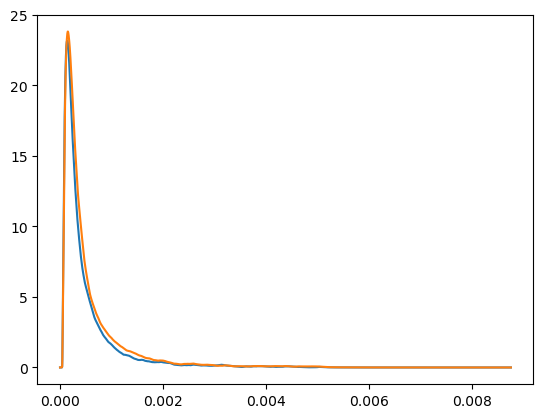

In [5]:
fig, ax = plt.subplots()
with open(file_list[0], 'rb') as f:
    evap = pickle.load(f)
s1, s2, time =generate_waveform(evap)
ax.plot(time, s1, label='CPD1')
ax.plot(time, s2, label='CPD2')

[ 0  6 12 18 24 30 36 42 48 54 60 66 72]


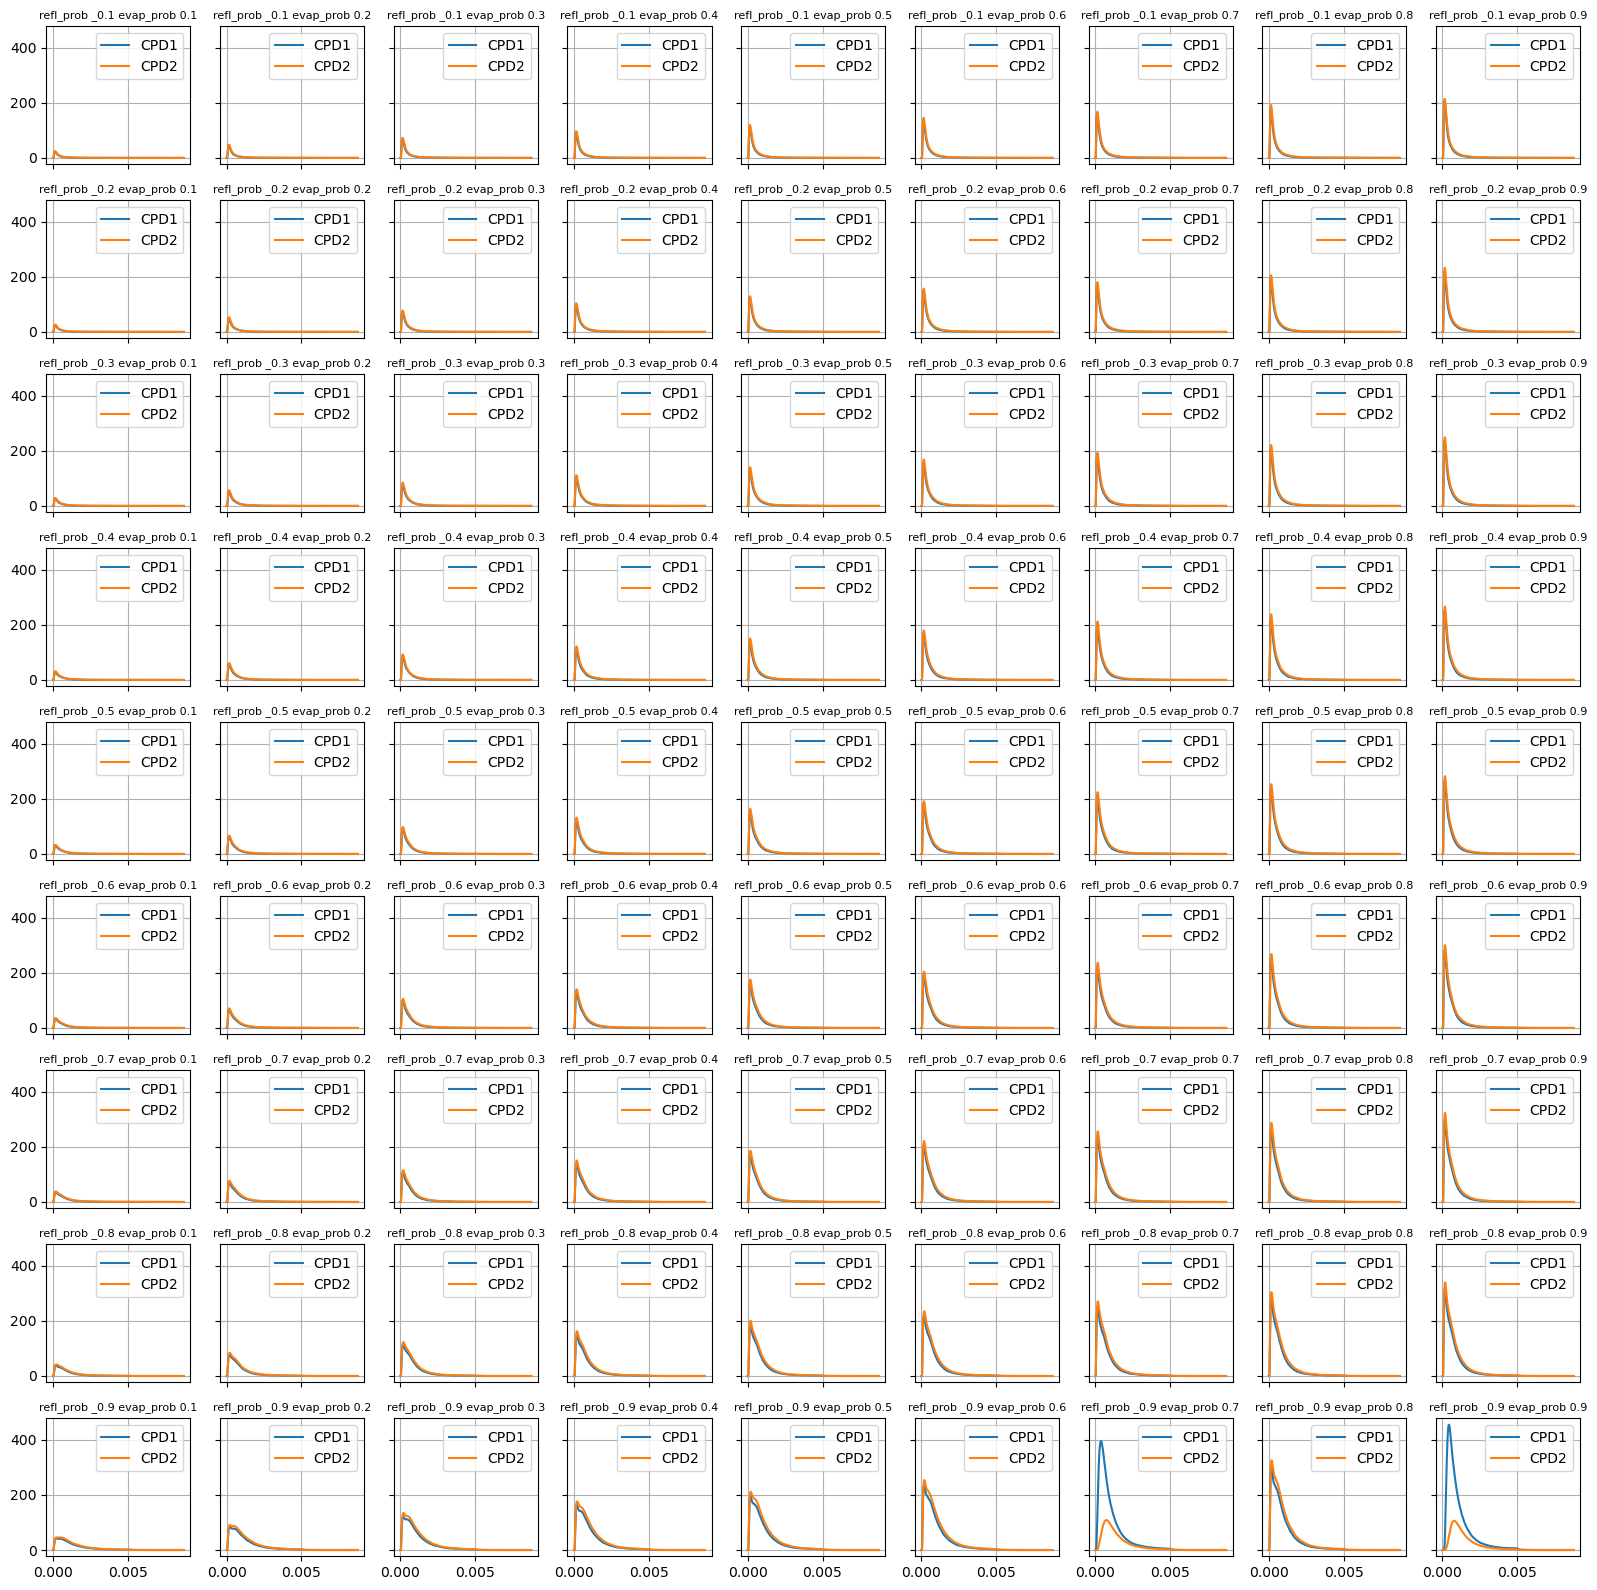

In [7]:

indices = np.arange(0, 78, 6, dtype=int)
print(indices)


fig, axs = plt.subplots(9, 9, figsize = (16,16), sharex=True, sharey=True)
ax = axs.flatten()
for i, f in enumerate(np.array(file_list)):
    with open(f, 'rb') as file:
        evap = pickle.load(file)
    title = f.split('/')[-1][:-4]
    refl_prob = title[-7:-4]
    evap_prob = title[-3:]
    s1, s2 , time =generate_waveform(evap)
    ax[i].plot(time, s1, label='CPD1')
    ax[i].plot(time, s2, label='CPD2')
    ax[i].set_title('refl_prob ' + refl_prob + ' evap_prob ' + evap_prob, fontsize=8)
    ax[i].legend()
    ax[i].grid()
fig.tight_layout()
 